# House Price — Regression Baselines

A reproducible baseline experiment following the shared 25-section assignment workflow.

## 01. Problem Definition

Predict the numeric house price per square-foot field and compare three regression models.

## 02. Import Libraries

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 03. Experiment Configuration

In [2]:
EXPERIMENT_NAME = "ml_baseline"
TARGET = "Price (in rupees)"
NUMERIC_FEATURES = ["Carpet Area Numeric", "Bathroom Numeric", "Balcony Numeric", "BHK"]
CATEGORICAL_FEATURES = ["location", "Status", "Transaction", "Furnishing", "facing", "Ownership"]
SELECTED_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
BEST_METRIC = "RMSE"

## 04. Paths

In [3]:
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data" / "house_prices.csv").exists(): PROJECT_DIR = Path("project/house-price-prediction")
DATA_DIR, FIGURE_DIR, MODEL_DIR, OUTPUT_DIR = (PROJECT_DIR / x for x in ("data", "figures", "models", "outputs"))
for directory in (FIGURE_DIR, MODEL_DIR, OUTPUT_DIR): directory.mkdir(parents=True, exist_ok=True)
print("Project directory:", PROJECT_DIR.resolve())

Project directory: D:\Nam_4\ki_1\HTTM\Assign_03\project\house-price-prediction


## 05. Load Dataset

In [4]:
df = pd.read_csv(DATA_DIR / "house_prices.csv")
print("Shape:", df.shape); display(df.head())

Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


## 06. Data Understanding

In [5]:
df.info(); display(df.describe(include="all").T)
print("Duplicate rows:", int(df.duplicated().sum()))
display(df.isna().sum().sort_values(ascending=False).head(12).to_frame("missing"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Duplicate rows: 0


,missing
Plot Area,187531
Dimensions,187531
Society,109678
Super Area,107685
Car Parking,103357
overlooking,81436
Carpet Area,80673
facing,70233
Ownership,65517
Balcony,48935


## 07. Data Cleaning

In [6]:
df = df.drop_duplicates().copy()
df = df[df[TARGET].notna() & (df[TARGET] > 0)].copy()

## 08. Feature Engineering

Parse numeric area/bathroom/balcony values and BHK from messy text. Parsing happens before splitting, but all learned imputing/encoding/scaling stays inside the pipelines.

In [7]:
df["Carpet Area Numeric"] = pd.to_numeric(df["Carpet Area"].str.extract(r"([\d,.]+)")[0].str.replace(",", "", regex=False), errors="coerce")
df["Bathroom Numeric"] = pd.to_numeric(df["Bathroom"].str.extract(r"(\d+(?:\.\d+)?)")[0], errors="coerce")
df["Balcony Numeric"] = pd.to_numeric(df["Balcony"].str.extract(r"(\d+(?:\.\d+)?)")[0], errors="coerce")
df["BHK"] = pd.to_numeric(df["Title"].str.extract(r"(\d+(?:\.\d+)?)\s*BHK", flags=2)[0], errors="coerce")

## 09. Feature Selection

In [8]:
X = df[SELECTED_FEATURES].copy(); y = df[TARGET].astype(float)
print("Rows:", len(X), "Features:", SELECTED_FEATURES); display(y.describe())

Rows: 169855 Features: ['Carpet Area Numeric', 'Bathroom Numeric', 'Balcony Numeric', 'BHK', 'location', 'Status', 'Transaction', 'Furnishing', 'facing', 'Ownership']


count    1.698550e+05
mean     7.584263e+03
std      2.724252e+04
min      1.000000e+00
25%      4.297000e+03
50%      6.034000e+03
75%      9.451000e+03
max      6.700000e+06
Name: Price (in rupees), dtype: float64

## 10. Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (135884, 10) Test: (33971, 10)


## 11. Preprocessing

In [10]:
numeric_scaled = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
numeric_tree = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=10))])
linear_prep = ColumnTransformer([("num", numeric_scaled, NUMERIC_FEATURES), ("cat", categorical, CATEGORICAL_FEATURES)])
tree_prep = ColumnTransformer([("num", numeric_tree, NUMERIC_FEATURES), ("cat", categorical, CATEGORICAL_FEATURES)])

## 12. Define 3 ML Models

In [11]:
models = {
 "Linear Regression": Pipeline([("prep", linear_prep), ("model", LinearRegression())]),
 "Decision Tree Regressor": Pipeline([("prep", tree_prep), ("model", DecisionTreeRegressor(max_depth=18, min_samples_leaf=5, random_state=RANDOM_STATE))]),
 "Random Forest Regressor": Pipeline([("prep", tree_prep), ("model", RandomForestRegressor(n_estimators=100, max_depth=22, min_samples_leaf=3, n_jobs=-1, random_state=RANDOM_STATE))]),
}
model_files = {"Linear Regression":"linear_regression.joblib", "Decision Tree Regressor":"decision_tree_regressor.joblib", "Random Forest Regressor":"random_forest_regressor.joblib"}

## 13. Train Models

In [12]:
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train); predictions[name] = model.predict(X_test); print("Trained:", name)

Trained: Linear Regression
Trained: Decision Tree Regressor
Trained: Random Forest Regressor


## 14. Evaluation Metrics

In [13]:
rows=[]
for name, pred in predictions.items():
    rows.append({"Model":name, "MAE":mean_absolute_error(y_test,pred), "RMSE":mean_squared_error(y_test,pred,squared=False), "R2":r2_score(y_test,pred)})

## 15. Model Comparison Table

In [14]:
results=pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True); display(results)

,Model,MAE,RMSE,R2
0,Linear Regression,2456.371948,3910.859636,0.357503
1,Random Forest Regressor,1069.083498,7450.057379,-1.331556
2,Decision Tree Regressor,1336.678061,9876.887561,-3.097951


## 16. Visualization

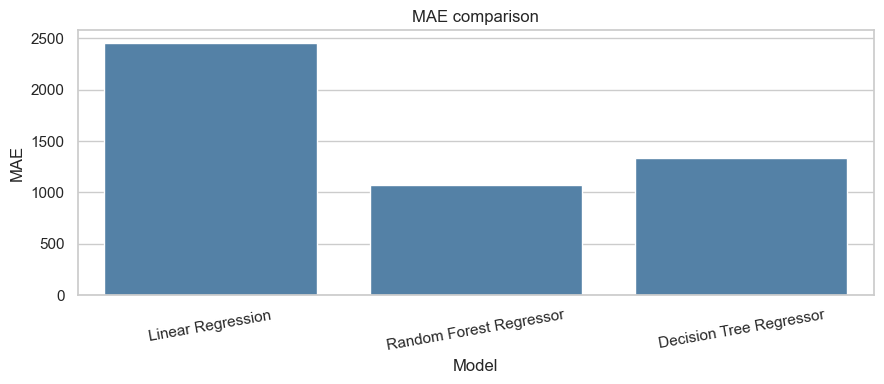

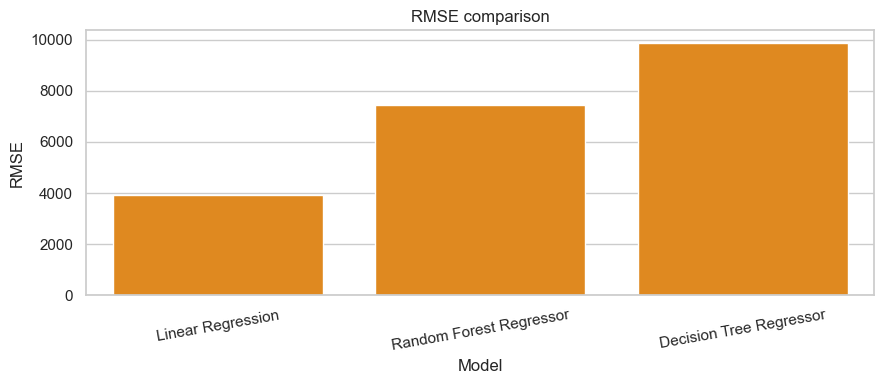

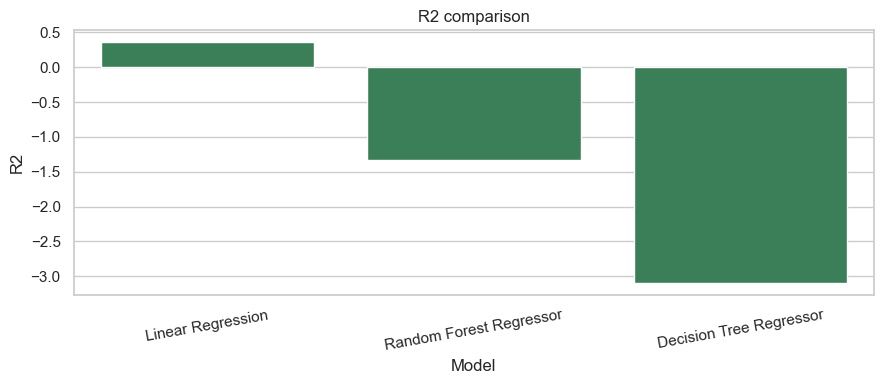

In [15]:
for metric, filename, color in [("MAE","mae_comparison.png","steelblue"),("RMSE","rmse_comparison.png","darkorange"),("R2","r2_comparison.png","seagreen")]:
    plt.figure(figsize=(9,4)); sns.barplot(data=results,x="Model",y=metric,color=color); plt.title(f"{metric} comparison"); plt.xticks(rotation=10); plt.tight_layout(); plt.savefig(FIGURE_DIR/filename,dpi=160); plt.show()

## 17. Select Best Model

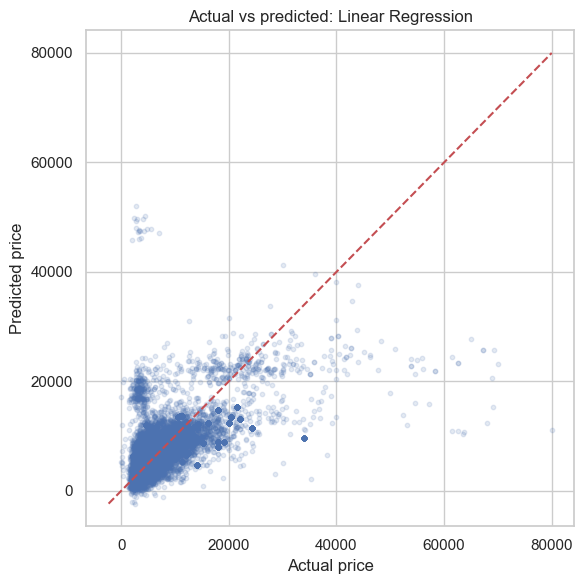

Best model by RMSE: Linear Regression


In [16]:
best_name=results.iloc[0]["Model"]; best_model=models[best_name]; best_pred=predictions[best_name]
plt.figure(figsize=(6,6)); plt.scatter(y_test,best_pred,alpha=.15,s=10); bounds=[min(y_test.min(),best_pred.min()),max(y_test.max(),best_pred.max())]; plt.plot(bounds,bounds,"r--"); plt.xlabel("Actual price"); plt.ylabel("Predicted price"); plt.title(f"Actual vs predicted: {best_name}"); plt.tight_layout(); plt.savefig(FIGURE_DIR/"actual_vs_predicted.png",dpi=160); plt.show()
print("Best model by RMSE:",best_name)

## 18. Save 3 Models

In [17]:
model_paths={}
for name,model in models.items():
    path=MODEL_DIR/model_files[name]; joblib.dump(model,path); model_paths[name]=path

## 19. Save Best Model

In [18]:
best_path=MODEL_DIR/"best_house_price_model.joblib"; joblib.dump(best_model,best_path)

['D:\\Nam_4\\ki_1\\HTTM\\Assign_03\\project\\house-price-prediction\\models\\best_house_price_model.joblib']

## 20. Save Results

In [19]:
results.to_csv(OUTPUT_DIR/"house_price_ml_results.csv",index=False)

## 21. Save Feature/Config

In [20]:
config={"experiment":EXPERIMENT_NAME,"task":"regression","target":TARGET,"features":SELECTED_FEATURES,"models":list(models),"best_metric":BEST_METRIC,"best_model":best_name,"random_state":RANDOM_STATE}
with open(OUTPUT_DIR/"model_config.json","w",encoding="utf-8") as f: json.dump(config,f,indent=2,ensure_ascii=False)

## 22. Reload 3 Models

In [21]:
loaded_models={name:joblib.load(path) for name,path in model_paths.items()}

## 23. Predict Test Sample

In [22]:
sample=X_test.iloc[[0]]; actual=float(y_test.iloc[0]); verification=[]
for name,model in loaded_models.items():
    pred=float(model.predict(sample)[0]); verification.append({"Model":name,"Predicted Price":pred,"Actual Price":actual,"Absolute Error":abs(pred-actual)})
display(pd.DataFrame(verification))

,Model,Predicted Price,Actual Price,Absolute Error
0,Linear Regression,6395.092497,2228.0,4167.092497
1,Decision Tree Regressor,5554.367125,2228.0,3326.367125
2,Random Forest Regressor,2992.319141,2228.0,764.319141


## 24. Verify Saved Models

In [23]:
for name in models: np.testing.assert_allclose(loaded_models[name].predict(sample),models[name].predict(sample))
assert joblib.load(best_path).predict(sample).shape==(1,)
print("[OK] All saved models loaded and predicted successfully.")

[OK] All saved models loaded and predicted successfully.


## 25. Conclusion

In [24]:
print(f"Best model: {best_name} | RMSE={results.iloc[0]['RMSE']:.2f} | R²={results.iloc[0]['R2']:.4f}")
print("Saved deployable preprocessing+model pipelines; lower MAE/RMSE and higher R² are better.")

Best model: Linear Regression | RMSE=3910.86 | R²=0.3575
Saved deployable preprocessing+model pipelines; lower MAE/RMSE and higher R² are better.
